<div style="display:flex; align-items:center; justify-content:space-between; background:linear-gradient(135deg,#0F0F1A 0%,#1A1A2E 100%); padding:28px 36px; border-radius:14px; margin-bottom:16px;">
  <div>
    <h1 style="color:white; margin:0; font-size:2.2em; font-weight:900;">Semana 3 · Matplotlib y Visualización de Datos</h1>
    <p style="color:#00C9A7; margin:8px 0 0; font-size:1.1em;">Data Science Fundamentals — SKILLNEST</p>
    <p style="color:#888; margin:4px 0 0; font-size:0.9em;">Repaso GroupBy/Apply → Matplotlib → Seaborn → Simulacro</p>
  </div>
  <img src="images/LOGO-CORREO_x.png" width="130"/>
</div>

## 📅 Agenda de la Semana

| Sesión | Horario | Tema Principal | Taller (22:00–23:00) |
|--------|---------|----------------|----------------------|
| **Clase 1** | 18:00 – 22:00 | Repaso GroupBy/Apply · Introducción a Matplotlib | Práctica líneas, scatter y barras |
| **Clase 2** | 18:00 – 22:00 | Histogramas, Diagramas de Caja y Subplots | Práctica distribuciones |
| **Clase 3** | 18:00 – 22:00 | Seaborn y Explicabilidad Visual | Dashboard con Seaborn |
| **Clase 4** | 18:00 – 22:00 | Simulacro de Examen | Corrección y retroalimentación |

---

<div style="background: linear-gradient(135deg, #1A1A2E 0%, #3B2F6E 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <div style="display:flex; align-items:center; gap:14px;">
    <span style="font-size:2em;">🔁</span>
    <div>
      <h2 style="color:white; margin:0; font-size:1.5em; font-weight:900; letter-spacing:0.5px;">Repaso — GroupBy y Apply</h2>
      <p style="color:rgba(255,255,255,0.85); margin:6px 0 0; font-size:1em;">Repasamos herramientas de pandas que usaremos para motivar la visualización</p>
    </div>
  </div>
</div>

## `groupby` — Agrupar y agregar

`groupby` permite **dividir** el DataFrame en grupos según una columna, **aplicar** una función a cada grupo y **combinar** los resultados.

```
df.groupby("columna_clave")["columna_valor"].funcion()
```

| Función | Resultado |
|---------|-----------|
| `.mean()` | Promedio por grupo |
| `.sum()` | Suma por grupo |
| `.count()` | Conteo por grupo |
| `.max()` / `.min()` | Máximo / mínimo por grupo |
| `.agg({"col1": "mean", "col2": "sum"})` | Múltiples funciones |

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("./data/pokemon.csv")
print(f"Dataset: {df.shape[0]} pokémon, {df.shape[1]} columnas")
df.head(3)

Dataset: 800 pokémon, 13 columnas


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False


In [2]:
df.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

In [3]:
# ¿Cuántos pokémon hay por tipo principal?
conteo = df.groupby("Type 1").size().sort_values(ascending=False)
print("Top 10 tipos más comunes:")
print(conteo.head(10))

Top 10 tipos más comunes:
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Dragon       32
dtype: int64


In [4]:
# ¿Cuál es el promedio de estadísticas por tipo?
stats_por_tipo = df.groupby("Type 1").agg(
    Cantidad    = ("Name", "count"),
    HP_prom     = ("HP", "mean"),
    Ataque_prom = ("Attack", "mean"),
    Total_prom  = ("Total", "mean")
).sort_values("Total_prom", ascending=False).round(1)

print("Top 5 tipos por stats totales promedio:")
print(stats_por_tipo.head(5))

Top 5 tipos por stats totales promedio:
         Cantidad  HP_prom  Ataque_prom  Total_prom
Type 1                                             
Dragon         32     83.3        112.1       550.5
Steel          27     65.2         92.7       487.7
Flying          4     70.8         78.8       485.0
Psychic        57     70.6         71.5       475.9
Fire           52     69.9         84.8       458.1


## `apply` — Aplicar funciones personalizadas

`apply` ejecuta una **función propia** sobre cada fila o columna. Es útil cuando ninguna función de pandas hace exactamente lo que necesitamos.

In [5]:
def clasificar_pokemon(total):
    if total >= 600:
        return "⭐ Legendario"
    elif total >= 450:
        return "💪 Fuerte"
    elif total >= 300:
        return "🔵 Normal"
    else:
        return "⚪ Débil"

df["Nivel"] = df["Total"].apply(clasificar_pokemon)

# Distribución resultante
print(df["Nivel"].value_counts())
print()
print(df[["Name", "Total", "Nivel"]].sample(6, random_state=42).to_string(index=False))

Nivel
💪 Fuerte        318
🔵 Normal        295
⚪ Débil         102
⭐ Legendario     85
Name: count, dtype: int64

           Name  Total        Nivel
      Hydreigon    600 ⭐ Legendario
       Beheeyem    485     💪 Fuerte
      Growlithe    350     🔵 Normal
RotomWash Rotom    520     💪 Fuerte
      Poliwhirl    385     🔵 Normal
        Scrafty    488     💪 Fuerte


## 🤔 ¿Qué tipo de pokémon es más fuerte en ataque?

Podemos responderlo con `groupby`:

```python
df.groupby("Type 1")["Attack"].mean().sort_values(ascending=False).head(5)
```

Pero... **¿cómo lo comunicamos de forma clara a alguien que no sabe de código?**

> **→ Necesitamos visualización.** Una tabla con 18 tipos es difícil de procesar. Un gráfico de barras lo dice en 2 segundos.

---

<div style="background:#1A1A2E; border-left:4px solid #00C9A7; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#00C9A7; font-weight:700; margin:0 0 6px;">✏️ Mini-ejercicio R1 — Repaso GroupBy</p>
  <p style="color:#CCC; margin:0;">Usa groupby para encontrar: (a) el tipo con mayor Defensa promedio, (b) cuántos pokémon Legendarios hay por Generación. Muestra los resultados.</p>
</div>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
 13  Nivel       800 non-null    object
dtypes: bool(1), int64(9), object(4)
memory usage: 82.2+ KB


In [7]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
# (a) Tipo con mayor Defensa promedio
# Tu código aquí:
df.groupby("Type 1")["Defense"].mean().sort_values(ascending=False)

Type 1
Steel       126.370370
Rock        100.795455
Dragon       86.375000
Ground       84.843750
Ghost        81.187500
Water        72.946429
Ice          71.416667
Grass        70.800000
Bug          70.724638
Dark         70.225806
Poison       68.821429
Fire         67.769231
Psychic      67.684211
Electric     66.295455
Flying       66.250000
Fighting     65.925926
Fairy        65.705882
Normal       59.846939
Name: Defense, dtype: float64

In [10]:
# (b) Legendarios por Generación
# Tu código aquí:
df.groupby("Generation")['Legendary'].sum()

Generation
1     6
2     5
3    18
4    13
5    15
6     8
Name: Legendary, dtype: int64

<div style="background: linear-gradient(135deg, #6C3CE1 0%, #00C9A7 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <div style="display:flex; align-items:center; gap:14px;">
    <span style="font-size:2em;">📊</span>
    <div>
      <h2 style="color:white; margin:0; font-size:1.5em; font-weight:900; letter-spacing:0.5px;">Clase 1 — Introducción a Matplotlib</h2>
      <p style="color:rgba(255,255,255,0.85); margin:6px 0 0; font-size:1em;">18:00 – 22:00 · Figuras, líneas, scatter y barras</p>
    </div>
  </div>
</div>

## ¿Qué es Matplotlib?

**Matplotlib** es la biblioteca de visualización más usada en Python. Es la base sobre la que se construyen Seaborn, Pandas plots y muchas otras herramientas.

```python
import matplotlib.pyplot as plt
```

### ¿Por qué visualizar datos?

- Las tablas muestran números; los gráficos muestran **patrones**
- Detectamos outliers, tendencias y distribuciones de un vistazo
- Es la forma más poderosa de comunicar resultados

### Anatomía de una figura

```
Figure (el lienzo completo)
└── Axes (el área de dibujo — puede haber varios)
    ├── Title (título del gráfico)
    ├── X-axis: label + ticks
    ├── Y-axis: label + ticks
    ├── Legend (leyenda)
    └── Plot (la visualización en sí)
```

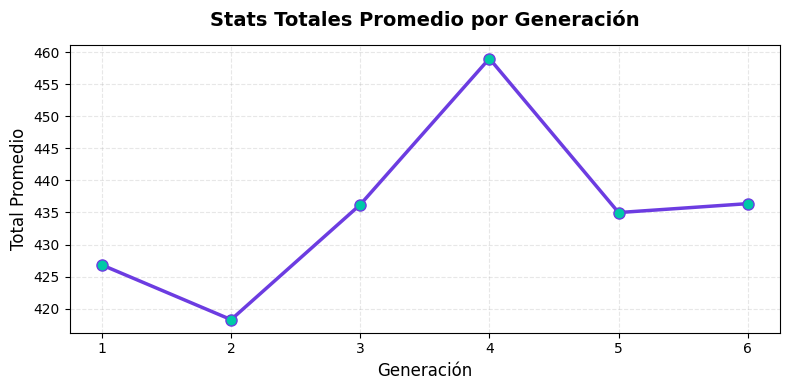

In [11]:
import matplotlib.pyplot as plt

# La forma recomendada: fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(8, 4))

# Datos simples
generaciones = [1, 2, 3, 4, 5, 6]
total_prom = df.groupby("Generation")["Total"].mean().values

ax.plot(generaciones, total_prom, color="#6C3CE1", linewidth=2.5,
        marker="o", markersize=8, markerfacecolor="#00C9A7")

ax.set_title("Stats Totales Promedio por Generación", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Generación", fontsize=12)
ax.set_ylabel("Total Promedio", fontsize=12)
ax.set_xticks(generaciones)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

## Parámetros comunes de personalización

| Parámetro | Valores de ejemplo | Efecto |
|-----------|-------------------|--------|
| `color` | `"#6C3CE1"`, `"red"`, `"steelblue"` | Color |
| `linewidth` / `lw` | `1`, `2.5`, `4` | Grosor de línea |
| `linestyle` / `ls` | `"-"`, `"--"`, `":"`, `"-."` | Estilo de línea |
| `marker` | `"o"`, `"s"`, `"^"`, `"*"` | Marcador de punto |
| `alpha` | `0.0` a `1.0` | Transparencia |
| `label` | `"Legendarios"` | Nombre en leyenda |
| `figsize` | `(10, 6)` | Tamaño en pulgadas |

## Gráfico de Dispersión (Scatter)

Ideal para explorar **relaciones entre dos variables numéricas**.

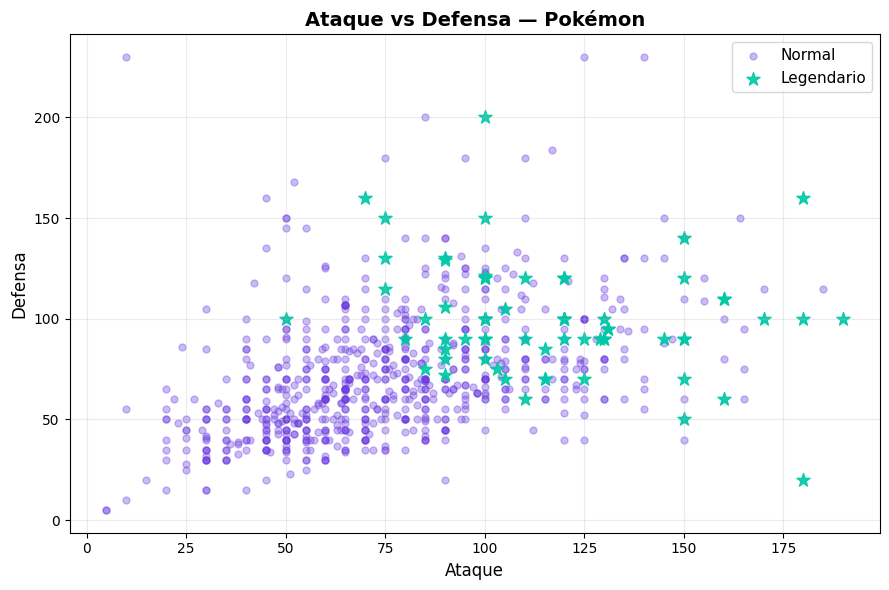

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

normales   = df[df["Legendary"] == False]
legendarios = df[df["Legendary"] == True]

ax.scatter(normales["Attack"], normales["Defense"],
           alpha=0.35, color="#6C3CE1", label="Normal", s=25)
ax.scatter(legendarios["Attack"], legendarios["Defense"],
           alpha=0.9, color="#00C9A7", label="Legendario", s=100, marker="*")

ax.set_title("Ataque vs Defensa — Pokémon", fontsize=14, fontweight="bold")
ax.set_xlabel("Ataque", fontsize=12)
ax.set_ylabel("Defensa", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Gráfico de Barras (Bar Chart)

Ideal para **comparar categorías** o mostrar rankings.

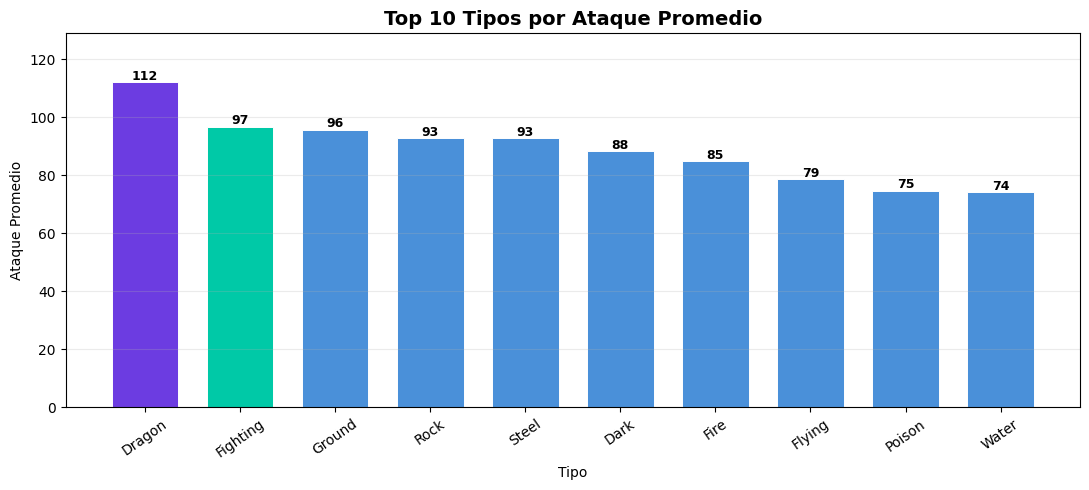

In [13]:
# Ataque promedio por tipo — Top 10
top_tipos = df.groupby("Type 1")["Attack"].mean().sort_values(ascending=False).head(10)

colores = ["#6C3CE1" if i == 0 else "#00C9A7" if i == 1 else "#4A90D9" for i in range(len(top_tipos))]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_tipos.index, top_tipos.values, color=colores, edgecolor="white", linewidth=0.7, width=0.7)

# Etiquetas de valor sobre cada barra
for bar, val in zip(bars, top_tipos.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val:.0f}", ha="center", fontsize=9, color="black", fontweight="bold")

ax.set_title("Top 10 Tipos por Ataque Promedio", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo")
ax.set_ylabel("Ataque Promedio")
ax.tick_params(axis="x", rotation=35)
ax.set_ylim(0, top_tipos.max() * 1.15)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

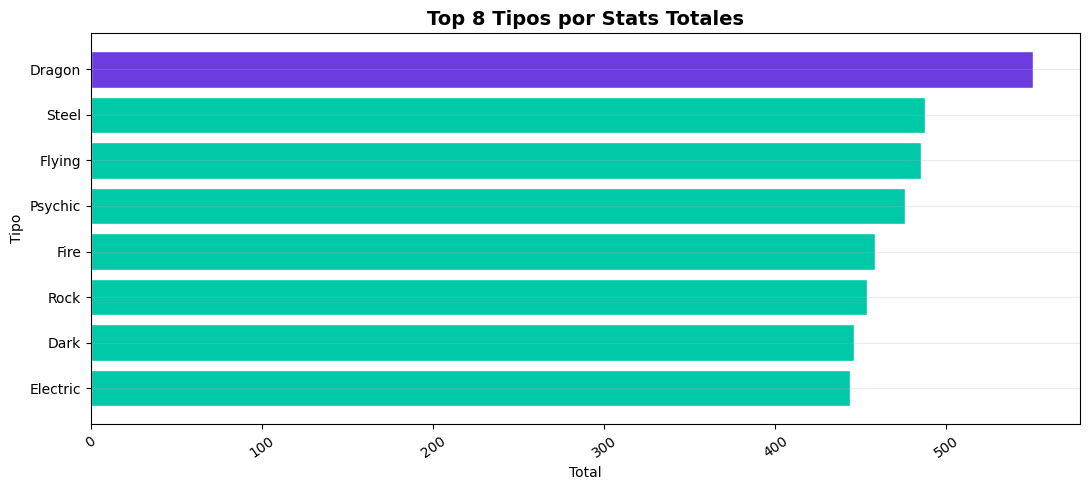

In [54]:
# Ataque promedio por tipo — Top 10
top_tipos8 = df.groupby("Type 1")["Total"].mean().sort_values(ascending=True).tail(8)
colores = ["#6C3CE1" if i == 7 else "#00C9A7" for i in range(len(top_tipos))]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_tipos8.index, top_tipos8.values, color=colores, edgecolor="white")


ax.set_title("Top 8 Tipos por Stats Totales", fontsize=14, fontweight="bold")
ax.set_xlabel("Total")
ax.set_ylabel("Tipo")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Guardar gráficos

```python
plt.savefig("mi_grafico.png", dpi=150, bbox_inches="tight")
plt.savefig("mi_grafico.svg", format="svg")   # Vector — escala sin perder calidad
```

- `dpi`: resolución (150–300 para presentaciones, 72 para web)
- `bbox_inches="tight"`: evita que se corten márgenes

<div style="background:#1A1A2E; border-left:4px solid #00C9A7; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#00C9A7; font-weight:700; margin:0 0 6px;">✏️ Mini-ejercicio C1 — Tu primer scatter</p>
  <p style="color:#CCC; margin:0;">Crea un scatter de HP (eje X) vs Speed (eje Y). Usa colores distintos para pokémon de Generación 1 vs el resto. Añade título, etiquetas y leyenda.</p>
</div>

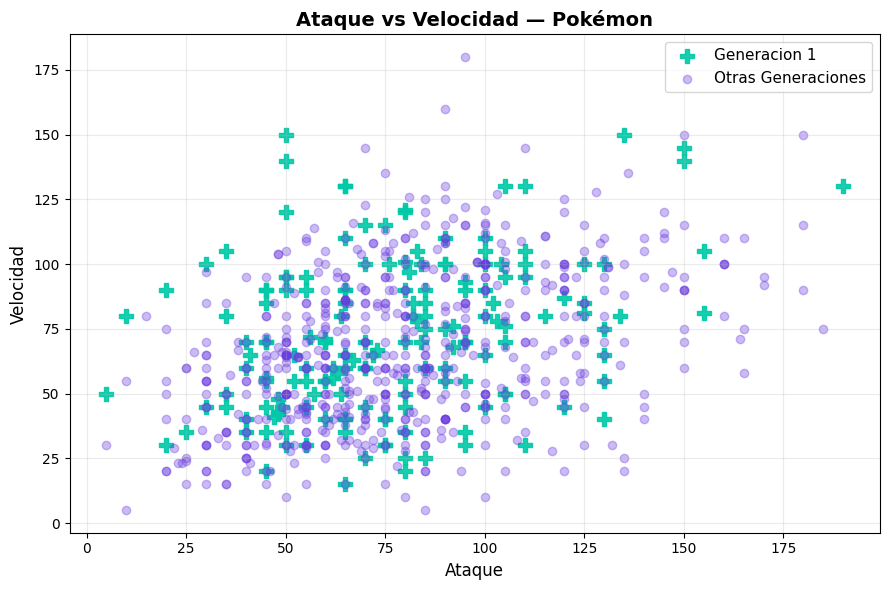

In [14]:
# Mini-ejercicio C1
# Tu código aquí:
fig, ax = plt.subplots(figsize=(9, 6))

gen1   = df[df["Generation"] == 1]
OtrasGen = df[df["Generation"] != 1]

ax.scatter(gen1["Attack"], gen1["Speed"],
           alpha=0.9, color="#00C9A7", label="Generacion 1", marker="P", s=100)
ax.scatter(OtrasGen["Attack"], OtrasGen["Speed"],
           alpha=0.35, color="#6C3CE1", label="Otras Generaciones")

ax.set_title("Ataque vs Velocidad — Pokémon", fontsize=14, fontweight="bold")
ax.set_xlabel("Ataque", fontsize=12)
ax.set_ylabel("Velocidad", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, #1A1A2E 0%, #00503E 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <div style="display:flex; align-items:center; gap:14px;">
    <span style="font-size:2em;">📦</span>
    <div>
      <h2 style="color:white; margin:0; font-size:1.5em; font-weight:900; letter-spacing:0.5px;">Clase 2 — Histogramas, Box Plots y Subplots</h2>
      <p style="color:rgba(255,255,255,0.85); margin:6px 0 0; font-size:1em;">18:00 – 22:00 · Distribuciones y composición de gráficos</p>
    </div>
  </div>
</div>

## Histogramas — Ver cómo se distribuyen los datos

Un histograma divide el rango de valores en **bins (intervalos)** y muestra cuántos datos caen en cada uno.

```python
ax.hist(datos, bins=30, color="...", edgecolor="white", alpha=0.8)
```

> **Regla de oro:** Si el histograma tiene forma de campana, los datos son aproximadamente normales.
> Si está sesgado, la media y la mediana serán diferentes.

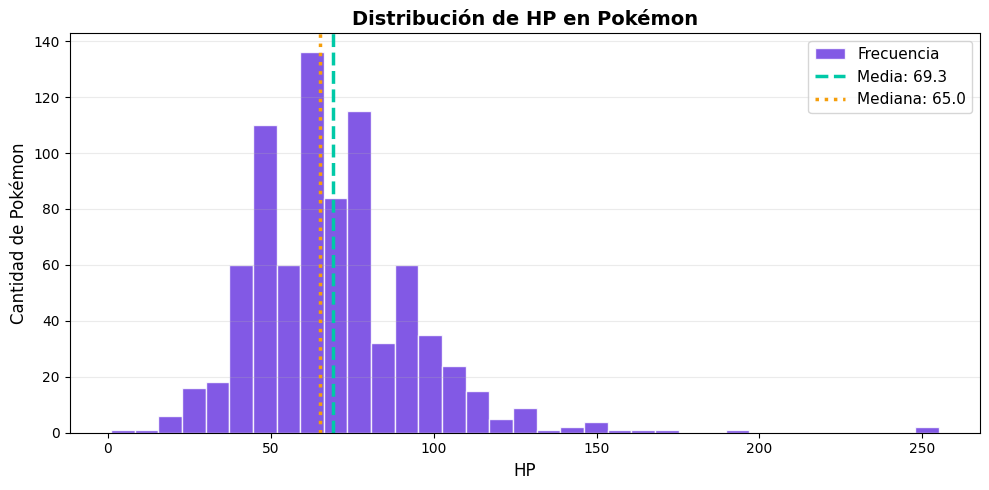

Asimetría (skewness): 1.568  →  sesgado a la derecha


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df["HP"], bins=35, color="#6C3CE1", edgecolor="white", alpha=0.85, label="Frecuencia")

media   = df["HP"].mean()
mediana = df["HP"].median()
ax.axvline(media,   color="#00C9A7", linewidth=2.5, linestyle="--", label=f"Media: {media:.1f}")
ax.axvline(mediana, color="#F59E0B", linewidth=2.5, linestyle=":",  label=f"Mediana: {mediana:.1f}")

ax.set_title("Distribución de HP en Pokémon", fontsize=14, fontweight="bold")
ax.set_xlabel("HP", fontsize=12)
ax.set_ylabel("Cantidad de Pokémon", fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print(f"Asimetría (skewness): {df['HP'].skew():.3f}  →  {'sesgado a la derecha' if df['HP'].skew() > 0 else 'sesgado a la izquierda'}")

### El efecto de los bins

Elegir pocos bins oculta detalles; demasiados muestran ruido.

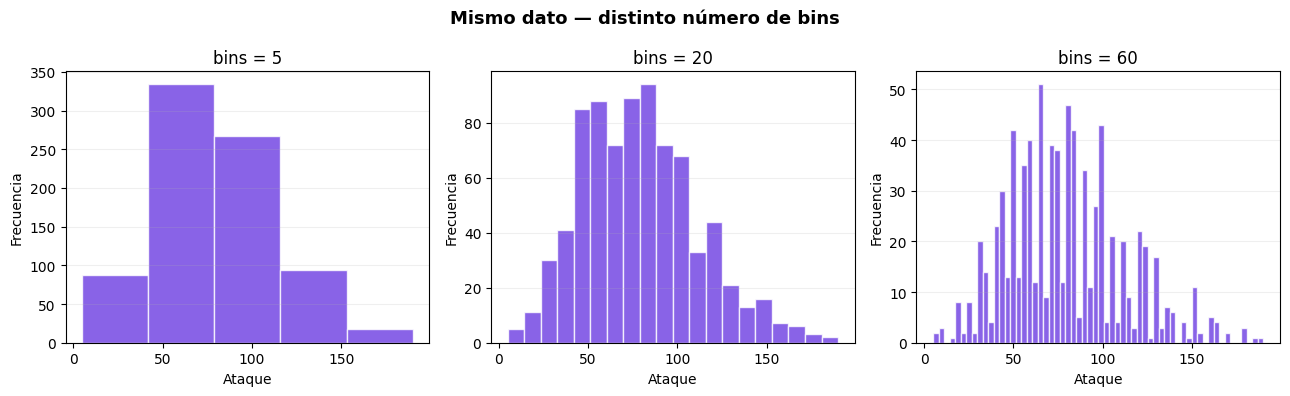

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Mismo dato — distinto número de bins", fontsize=13, fontweight="bold")

for ax, bins in zip(axes, [5, 20, 60]):
    ax.hist(df["Attack"], bins=bins, color="#6C3CE1", edgecolor="white", alpha=0.8)
    ax.set_title(f"bins = {bins}")
    ax.set_xlabel("Ataque")
    ax.set_ylabel("Frecuencia")
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## Box Plot (Diagrama de Caja)

Resume la **distribución estadística** de los datos y detecta outliers.

```
|----[ Q1 | MEDIANA | Q3 ]----| ●  ← outlier
     ↑                    ↑
   bigote               bigote
```

| Elemento | Qué muestra |
|----------|-------------|
| Caja | Rango intercuartílico (IQR = Q3 − Q1) → 50% central |
| Línea central | Mediana |
| Bigotes | Hasta 1.5×IQR desde Q1/Q3 |
| Puntos | Outliers (fuera de los bigotes) |

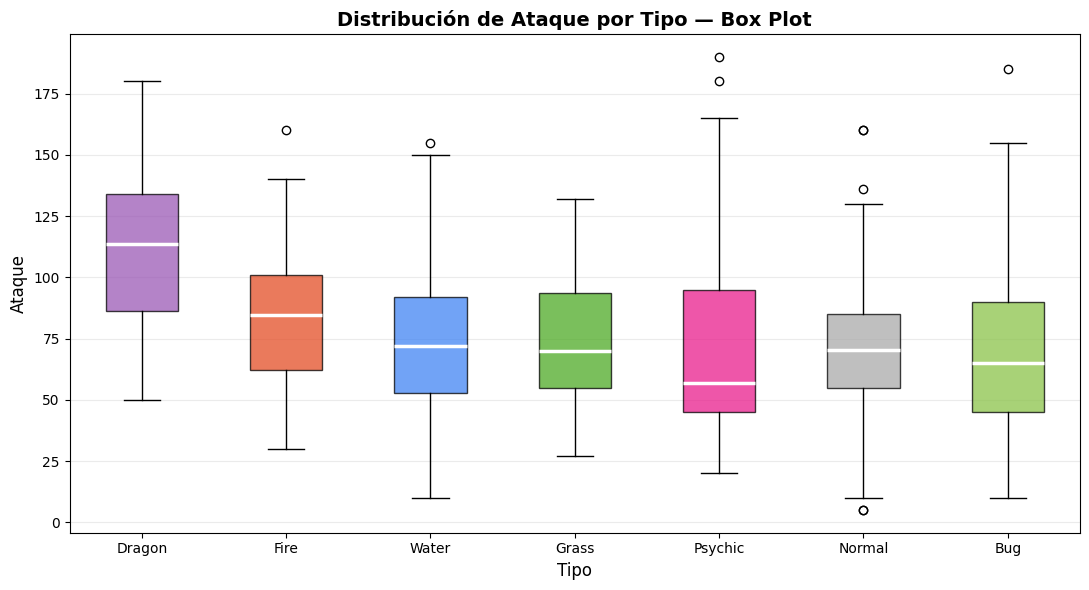

In [17]:
tipos_sel = ["Dragon", "Fire", "Water", "Grass", "Psychic", "Normal", "Bug"]
datos_box = [df[df["Type 1"] == t]["Attack"].values for t in tipos_sel]
colores   = ["#9B59B6", "#E44D26", "#4285F4", "#4EAA25", "#E91E8C", "#AAA", "#8BC34A"]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(datos_box, patch_artist=True, tick_labels=tipos_sel,
                medianprops=dict(color="white", linewidth=2.5))

for patch, color in zip(bp["boxes"], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title("Distribución de Ataque por Tipo — Box Plot", fontsize=14, fontweight="bold")
ax.set_ylabel("Ataque", fontsize=12)
ax.set_xlabel("Tipo", fontsize=12)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Subplots — Varios gráficos en una figura

```python
fig, axes = plt.subplots(filas, columnas, figsize=(ancho, alto))
```

Accedemos a cada subgráfico con `axes[fila][col]` o usando `axes.flat` para iterar.

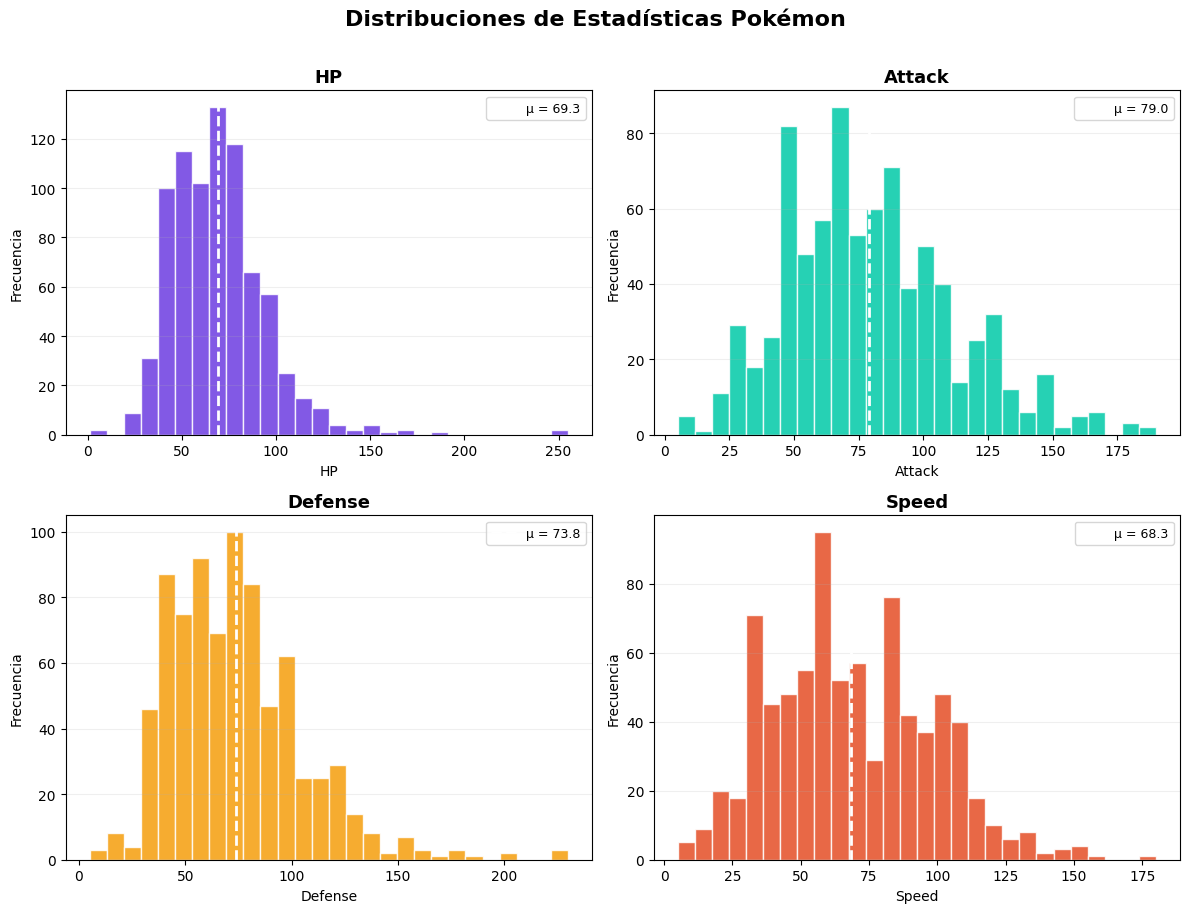

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Distribuciones de Estadísticas Pokémon", fontsize=16, fontweight="bold", y=1.01)

stats  = ["HP", "Attack", "Defense", "Speed"]
colors = ["#6C3CE1", "#00C9A7", "#F59E0B", "#E44D26"]

for ax, stat, color in zip(axes.flat, stats, colors):
    ax.hist(df[stat], bins=28, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df[stat].mean(), color="white", linewidth=2, linestyle="--",
               label=f"μ = {df[stat].mean():.1f}")
    ax.set_title(stat, fontsize=13, fontweight="bold")
    ax.set_xlabel(stat)
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

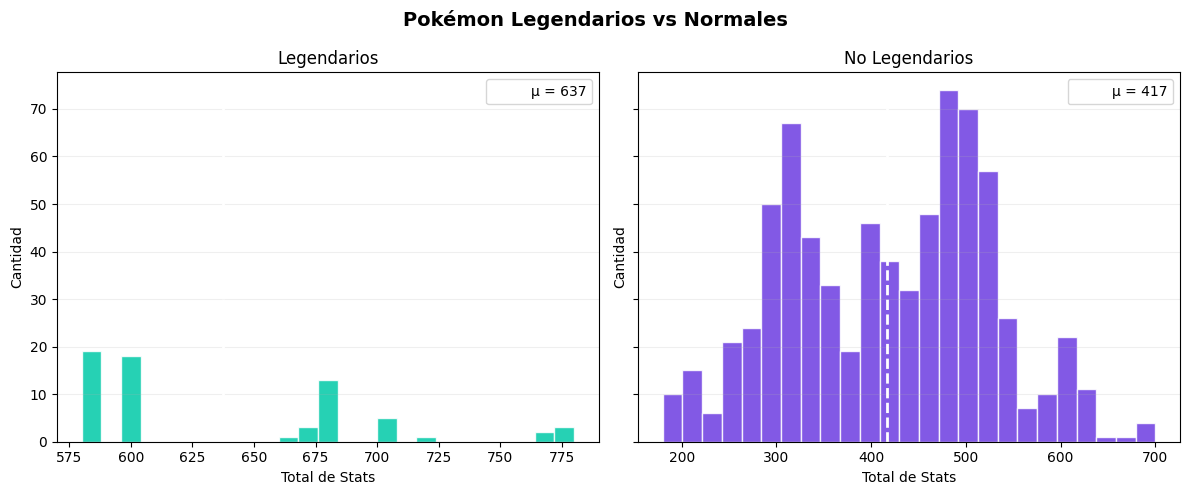

In [ ]:
# Subplot con ejes compartidos — util para comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle("Pokémon Legendarios vs Normales", fontsize=14, fontweight="bold")

for ax, legendario, color, titulo in zip(
    axes,
    [True, False],
    ["#00C9A7", "#6C3CE1"],
    ["Legendarios", "No Legendarios"]
):
    subset = df[df["Legendary"] == legendario]["Total"]
    ax.hist(subset, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Total de Stats")
    ax.set_ylabel("Cantidad")
    ax.axvline(subset.mean(), color="white", linewidth=2, linestyle="--",
               label=f"prom = {subset.mean():.0f}")
    ax.legend()
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

<div style="background:#1A1A2E; border-left:4px solid #00C9A7; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#00C9A7; font-weight:700; margin:0 0 6px;">✏️ Mini-ejercicio C2 — BoxPlot comparativo</p>
  <p style="color:#CCC; margin:0;">Crea una figura con 2 subplots: (izquierda) histograma de 'Sp. Atk', (derecha) boxplot de 'Sp. Atk' separado por Legendario/Normal. Comparte el eje Y entre los dos.</p>
</div>

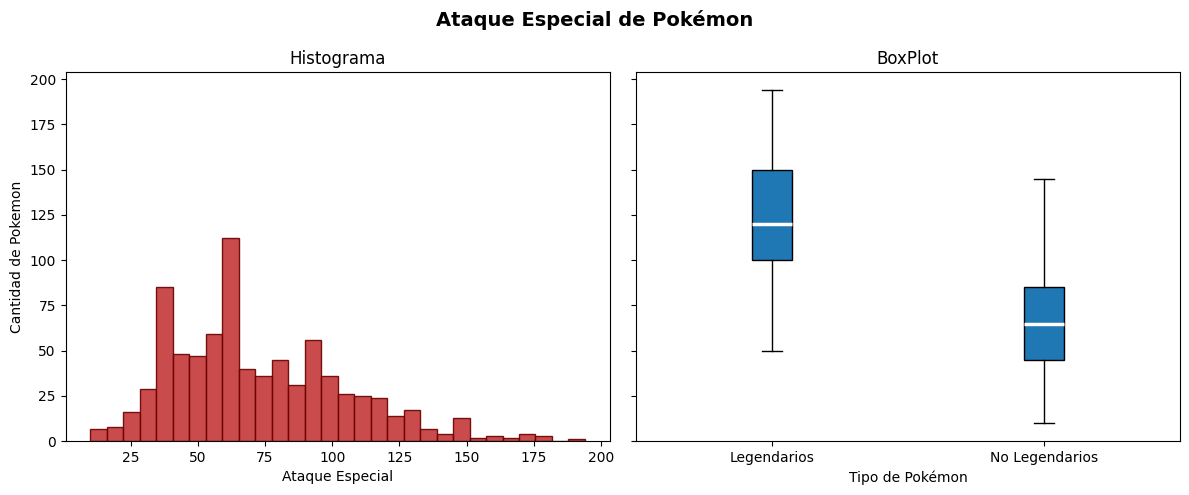

In [55]:
# Mini-ejercicio C2
# Tu código aquí:
# Subplot con ejes compartidos — util para comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle("Ataque Especial de Pokémon", fontsize=14, fontweight="bold")

axes[0].hist(df["Sp. Atk"], bins=30, color="#C53737", edgecolor="#690000", alpha=0.9)
axes[0].set_title("Histograma", fontsize=12)
axes[0].set_xlabel("Ataque Especial")
axes[0].set_ylabel("Cantidad de Pokemon")

axes[1].boxplot([df[df["Legendary"] == True]["Sp. Atk"], df[df["Legendary"] == False]["Sp. Atk"]],
                patch_artist=True, tick_labels=["Legendarios", "No Legendarios"],
                medianprops=dict(color="white", linewidth=2.5),showfliers=False)
axes[1].set_title("BoxPlot", fontsize=12)
axes[1].set_xlabel("Tipo de Pokémon")


plt.tight_layout()
plt.show()

<div style="background: linear-gradient(135deg, #1A1A2E 0%, #004080 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <div style="display:flex; align-items:center; gap:14px;">
    <span style="font-size:2em;">🎨</span>
    <div>
      <h2 style="color:white; margin:0; font-size:1.5em; font-weight:900; letter-spacing:0.5px;">Clase 3 — Seaborn y Explicabilidad Visual</h2>
      <p style="color:rgba(255,255,255,0.85); margin:6px 0 0; font-size:1em;">18:00 – 22:00 · Gráficos avanzados, correlación y lectura crítica</p>
    </div>
  </div>
</div>

## ¿Qué es Seaborn?

**Seaborn** está construida sobre Matplotlib. Genera gráficos más bonitos con menos código, y está diseñada para trabajar directamente con DataFrames.

```python
import seaborn as sns
```

| Gráfico | Función | Cuándo usarlo |
|---------|---------|---------------|
| Histograma + KDE | `sns.histplot(kde=True)` | Distribución de una variable |
| Caja | `sns.boxplot` | Comparar distribuciones por categoría |
| Barras | `sns.barplot` | Comparar medias con intervalo de confianza |
| Dispersión | `sns.scatterplot` | Relación entre dos variables |
| Heatmap | `sns.heatmap` | Matriz de correlación |
| Pairplot | `sns.pairplot` | Exploración inicial de todo el dataset |

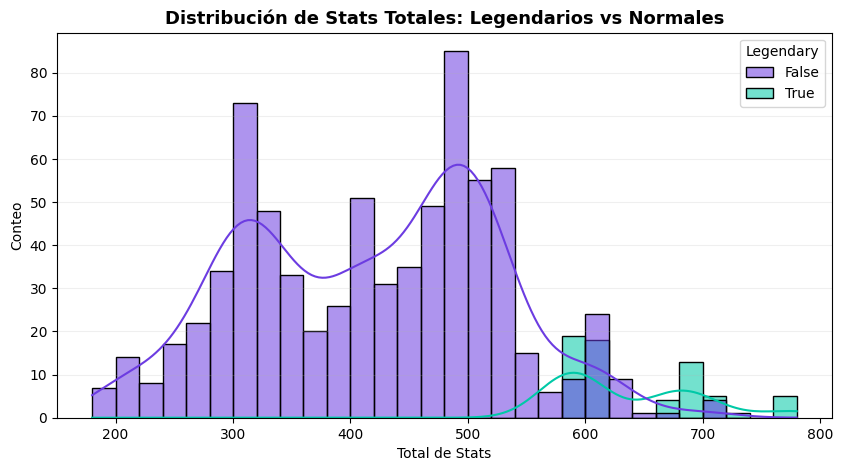

In [21]:
import seaborn as sns

# histplot con KDE (Kernel Density Estimation)
fig, ax = plt.subplots(figsize=(10, 5))

df_leg = df.copy()
df_leg["Legendary"] = df_leg["Legendary"].astype(str)

sns.histplot(data=df_leg, x="Total", hue="Legendary", kde=True, bins=30,
             palette={"True": "#00C9A7", "False": "#6C3CE1"}, alpha=0.55, ax=ax)

ax.set_title("Distribución de Stats Totales: Legendarios vs Normales", fontsize=13, fontweight="bold")
ax.set_xlabel("Total de Stats")
ax.set_ylabel("Conteo")
ax.grid(axis="y", alpha=0.2)
plt.show()

### Seaborn BoxPlot — interfaz de alto nivel

Con Seaborn el boxplot por categorías es mucho más simple que en Matplotlib puro.

C:\Users\jr_ca\AppData\Local\Temp\ipykernel_14128\3475996840.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


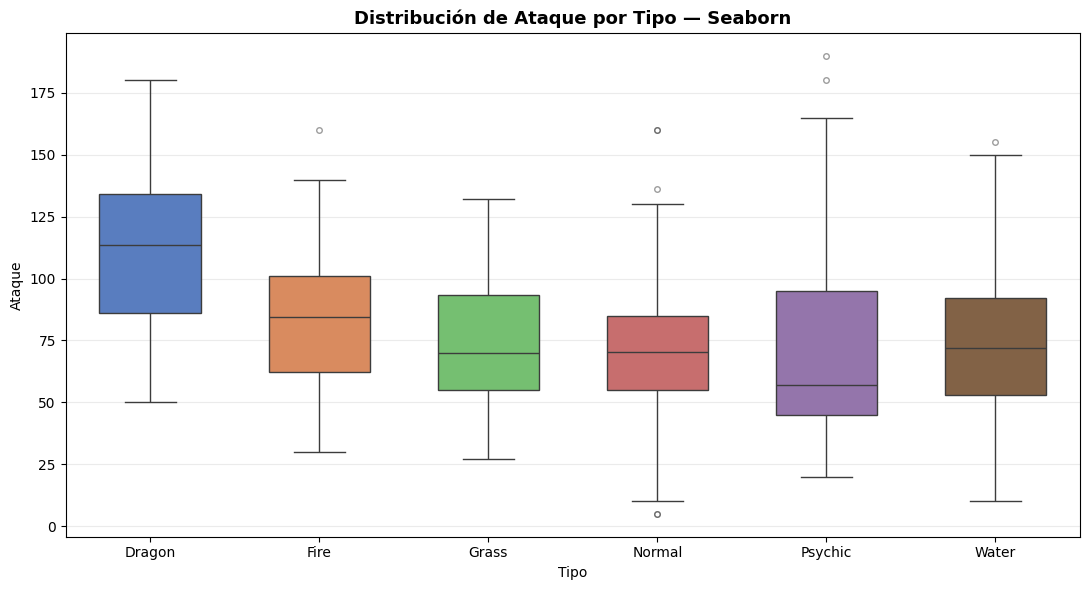

In [22]:
tipos_grafico = ["Dragon", "Fire", "Water", "Grass", "Psychic", "Normal"]
df_tipos = df[df["Type 1"].isin(tipos_grafico)]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df_tipos, x="Type 1", y="Attack", ax=ax,
    order=sorted(tipos_grafico),
    palette="muted",
    width=0.6, flierprops=dict(marker="o", markersize=4, alpha=0.5)
)
ax.set_title("Distribución de Ataque por Tipo — Seaborn", fontsize=13, fontweight="bold")
ax.set_xlabel("Tipo")
ax.set_ylabel("Ataque")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Seaborn Barplot — con intervalo de confianza

El barplot de Seaborn calcula automáticamente la media **y muestra el intervalo de confianza al 95%** (las barritas de error). Esto nos dice qué tan confiable es el promedio.

C:\Users\jr_ca\AppData\Local\Temp\ipykernel_14128\2161339295.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Generation", y="Total", order=orden_gen,


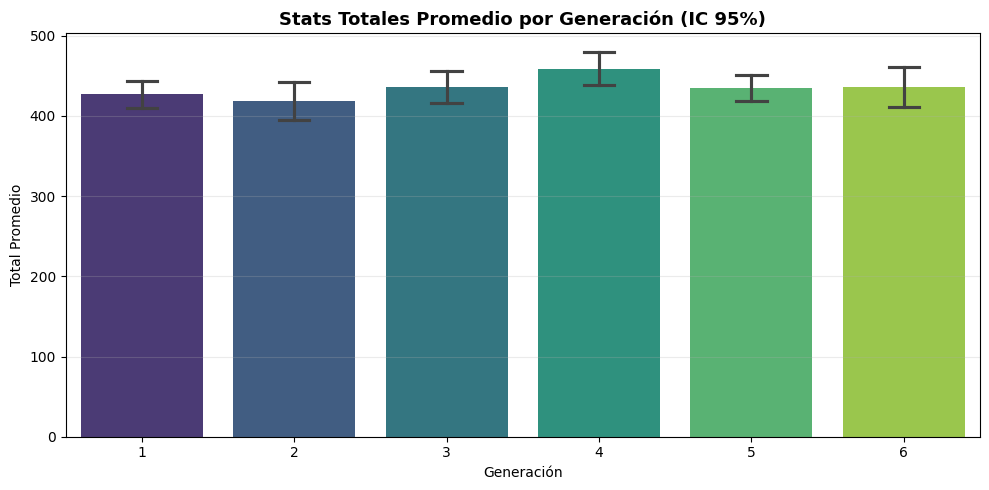

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

orden_gen = sorted(df["Generation"].unique())
sns.barplot(data=df, x="Generation", y="Total", order=orden_gen,
            palette="viridis", ax=ax, errorbar="ci", capsize=0.2)

ax.set_title("Stats Totales Promedio por Generación (IC 95%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Generación")
ax.set_ylabel("Total Promedio")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Heatmap de Correlación

La **correlación** mide qué tan relacionadas están dos variables numéricas:
- **+1.0**: correlación positiva perfecta (cuando una sube, la otra también)
- **−1.0**: correlación negativa perfecta (cuando una sube, la otra baja)
- **0**: no hay relación lineal

```python
df[columnas].corr()  →  matriz de correlación
```

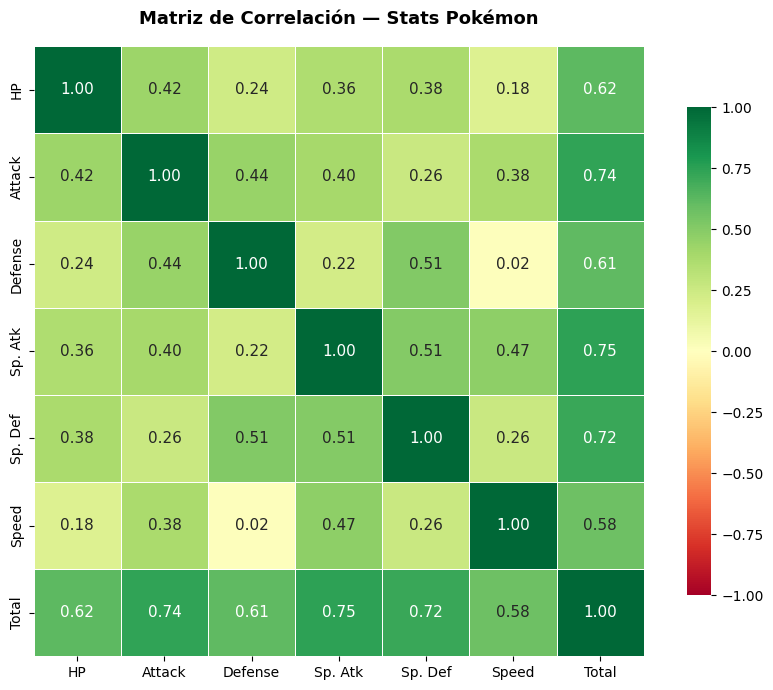

In [24]:
cols_num = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed", "Total"]
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={"size": 11}, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Matriz de Correlación — Stats Pokémon", fontsize=13, fontweight="bold", pad=16)
plt.tight_layout()
plt.show()

### ¿Qué nos dice este heatmap?

Leemos el heatmap buscando:
- **Verde intenso**: alta correlación positiva (ej: Total con Attack)
- **Rojo intenso**: correlación negativa (casi inexistente aquí)
- **Amarillo / blanco**: poca o ninguna correlación

> **Insight:** `Total` está muy correlacionado con todos los stats individuales — lógico, es la suma. `Speed` está menos correlacionado con `Defense`, lo que tiene sentido (pokémon rápidos no necesariamente son defensivos).

## Pairplot — Exploración visual rápida

Crea una cuadrícula de scatter plots para **todas las combinaciones de variables numéricas**. Perfecto para la exploración inicial.

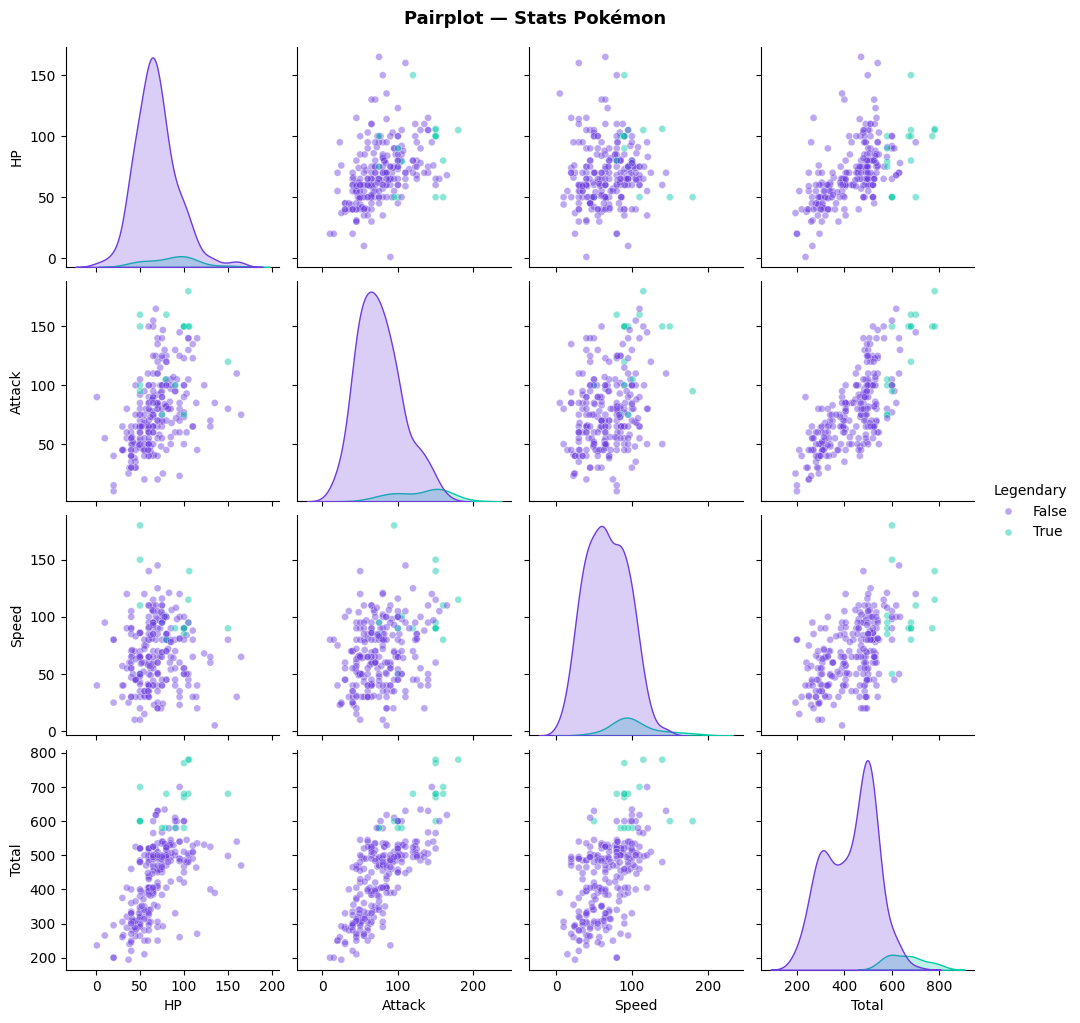

In [25]:
df_sample = df[["HP", "Attack", "Speed", "Total", "Legendary"]].sample(250, random_state=42).copy()
df_sample["Legendary"] = df_sample["Legendary"].astype(str)

pair = sns.pairplot(
    df_sample, hue="Legendary",
    palette={"True": "#00C9A7", "False": "#6C3CE1"},
    plot_kws={"alpha": 0.45, "s": 25},
    diag_kind="kde"
)
pair.fig.suptitle("Pairplot — Stats Pokémon", y=1.02, fontsize=13, fontweight="bold")
plt.show()

## Explicabilidad — Cómo leer e interpretar gráficos

Un gráfico sin contexto es solo una imagen. La **explicabilidad visual** es la capacidad de extraer conclusiones concretas.

### Checklist para leer un gráfico

1. **¿Qué representa cada eje?** — Lee los labels
2. **¿Cuál es la escala?** — Cuidado con ejes que no empiezan en 0
3. **¿Hay valores atípicos (outliers)?** — Los puntos alejados del resto
4. **¿Qué patrón o tendencia aparece?** — Ascendente, descendente, agrupado
5. **¿Qué conclusión puedo comunicar en una oración?**

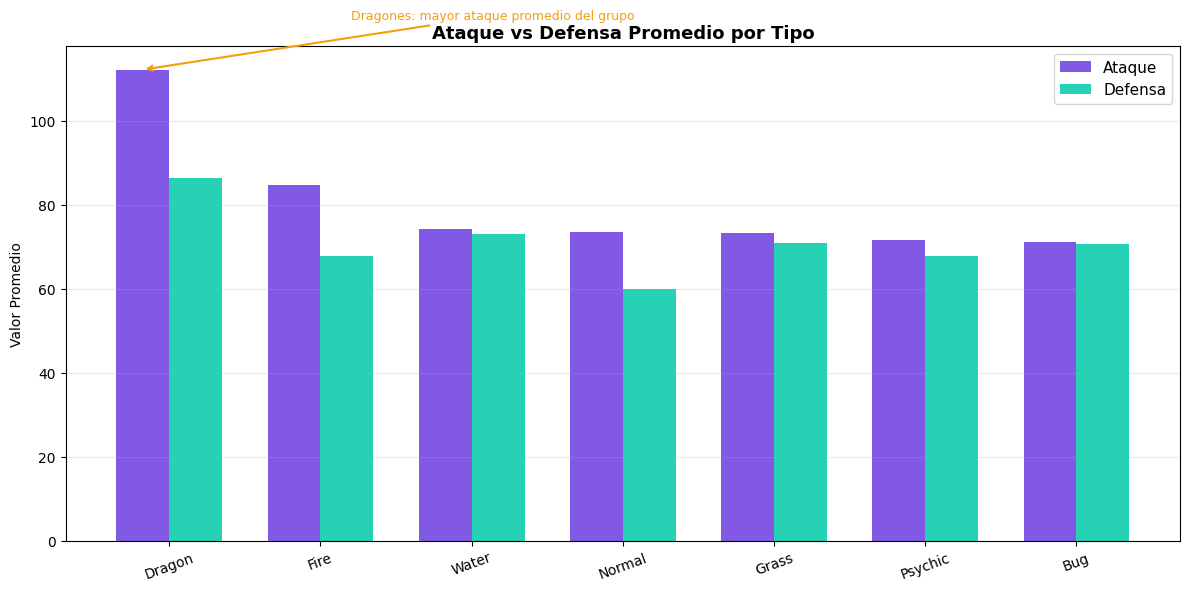


💡 Insight: Los Dragon tienen el mayor ataque promedio, pero Bug tiene la mayor defensa relativa a su ataque.


In [26]:
# Gráfico anotado — comunicando insights
tipos_anotados = ["Water", "Fire", "Grass", "Dragon", "Psychic", "Normal", "Bug"]
medias = df[df["Type 1"].isin(tipos_anotados)].groupby("Type 1")[["Attack", "Defense"]].mean()
medias_sorted = medias.sort_values("Attack", ascending=False)

x = range(len(medias_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], medias_sorted["Attack"],
               width, label="Ataque", color="#6C3CE1", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], medias_sorted["Defense"],
               width, label="Defensa", color="#00C9A7", alpha=0.85)

# Anotación con insight
dragon_idx = list(medias_sorted.index).index("Dragon")
ax.annotate(
    "Dragones: mayor ataque promedio del grupo",
    xy=(dragon_idx - width/2, medias_sorted.loc["Dragon", "Attack"]),
    xytext=(dragon_idx + 1.2, medias_sorted.loc["Dragon", "Attack"] + 12),
    fontsize=9, color="#F59E0B",
    arrowprops=dict(arrowstyle="->", color="#F59E0B", lw=1.5)
)

ax.set_title("Ataque vs Defensa Promedio por Tipo", fontsize=13, fontweight="bold")
ax.set_xticks(list(x))
ax.set_xticklabels(medias_sorted.index, rotation=20)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.25)
ax.set_ylabel("Valor Promedio")

plt.tight_layout()
plt.show()

print("\n💡 Insight: Los Dragon tienen el mayor ataque promedio, pero Bug tiene la mayor defensa relativa a su ataque.")

<div style="background:#1A1A2E; border-left:4px solid #00C9A7; padding:16px 20px; border-radius:8px; margin:20px 0;">
  <p style="color:#00C9A7; font-weight:700; margin:0 0 6px;">✏️ Mini-ejercicio C3 — Dashboard de Seaborn</p>
  <p style="color:#CCC; margin:0;">Crea una figura con 3 subplots usando Seaborn: (1) histplot de 'Speed' con KDE, (2) boxplot de 'Defense' por Generación, (3) barplot del promedio de 'Sp. Atk' por Type 1 (solo los 8 tipos más comunes). Añade título general.</p>
</div>

In [27]:
# Mini-ejercicio C3
# Tu código aquí:


<div style="background: linear-gradient(135deg, #1A1A2E 0%, #5C1A00 100%); padding: 28px 36px; border-radius: 14px; margin: 32px 0 20px;">
  <div style="display:flex; align-items:center; gap:14px;">
    <span style="font-size:2em;">📝</span>
    <div>
      <h2 style="color:white; margin:0; font-size:1.5em; font-weight:900; letter-spacing:0.5px;">Clase 4 — Simulacro de Examen</h2>
      <p style="color:rgba(255,255,255,0.85); margin:6px 0 0; font-size:1em;">18:00 – 22:00 · Evalúa tus conocimientos de las Semanas 1–3</p>
    </div>
  </div>
</div>

## Instrucciones

| Detalle | Valor |
|---------|-------|
| **Duración** | 3 horas |
| **Modalidad** | Individual, código propio |
| **Secciones** | Python (20 pts) · Pandas (40 pts) · Visualización (30 pts) |
| **Bonus** | 10 pts extra |
| **Total** | 100 pts (+10 bonus) |

> Puedes usar el notebook de la clase, la documentación de pandas y matplotlib.
> No se puede copiar código de compañeros.

---

<div style="background:linear-gradient(90deg,#6C3CE1,#3B1FA0); padding:14px 24px; border-radius:10px; margin:20px 0 12px;">
  <h3 style="color:white; margin:0;">🐍 SECCIÓN 1 — Python Fundamentals (20 pts)</h3>
</div>

<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 1</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">7 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">Función clasificadora con múltiples retornos</p>
  <p style="color:#CCC; margin:0;">Escribe una función <code>evaluar_pokemon(nombre, total, es_legendario)</code> que retorne un string con la evaluación. Si es legendario: siempre retorna 'LEGENDARIO ⭐'. Si no: 'FUERTE 💪' (total ≥ 450), 'NORMAL 🔵' (total ≥ 300), o 'DÉBIL ⚪'. Prueba la función con al menos 4 casos distintos.</p>
</div>

In [28]:
# Pregunta 1 — Tu código aquí:


<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 2</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">6 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">List comprehension y filtros</p>
  <p style="color:#CCC; margin:0;">Dada la lista <code>nombres = ['Charizard','Blastoise','Venusaur','Mewtwo','Pikachu','Raichu','Eevee','Snorlax','Gengar','Alakazam']</code>:<br>(a) Crea una lista con nombres que tengan más de 6 caracteres<br>(b) Crea una lista con nombres en MAYÚSCULAS que empiecen con vocal<br>(c) Cuenta cuántos nombres tienen exactamente 7 caracteres</p>
</div>

In [29]:
nombres = ["Charizard", "Blastoise", "Venusaur", "Mewtwo", "Pikachu",
           "Raichu", "Eevee", "Snorlax", "Gengar", "Alakazam"]

# (a) nombres con más de 6 caracteres
# Tu código aquí:

# (b) MAYÚSCULAS + empiezan con vocal
# Tu código aquí:

# (c) nombres con exactamente 7 caracteres
# Tu código aquí:


<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 3</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">7 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">Diccionarios y funciones</p>
  <p style="color:#CCC; margin:0;">Tienes un diccionario de pokemon. Escribe una función <code>analizar_stats(pokemon_dict)</code> que retorne un diccionario con: 'stat_max' (nombre del stat más alto), 'stat_min' (nombre del stat más bajo), 'promedio' (promedio de todos los stats redondeado a 1 decimal), 'clasificacion' ('Tanque' si Defense es el max, 'Atacante' si Attack es el max, 'Speedster' si Speed es el max, 'Balanceado' en otro caso).</p>
</div>

In [30]:
charizard = {"HP": 78, "Attack": 84, "Defense": 78, "Sp_Atk": 109, "Sp_Def": 85, "Speed": 100}
blastoise = {"HP": 79, "Attack": 83, "Defense": 100, "Sp_Atk": 85, "Sp_Def": 105, "Speed": 78}
raichu    = {"HP": 60, "Attack": 90, "Defense": 55, "Sp_Atk": 90, "Sp_Def": 80, "Speed": 110}

def analizar_stats(pokemon_dict):
    # Tu código aquí:
    pass

print(analizar_stats(charizard))
print(analizar_stats(blastoise))
print(analizar_stats(raichu))


None
None
None


<div style="background:linear-gradient(90deg,#00C9A7,#00705B); padding:14px 24px; border-radius:10px; margin:20px 0 12px;">
  <h3 style="color:white; margin:0;">🐼 SECCIÓN 2 — Pandas (40 pts)</h3>
</div>

<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 4</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">10 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">Carga, exploración y nuevas columnas</p>
  <p style="color:#CCC; margin:0;">Carga el dataset Pokemon. (a) Muestra las primeras 5 filas. (b) ¿Cuántos pokémon tienen Type 2 nulo? (c) Crea la columna 'Es_Rapido' (True si Speed > 100). (d) Crea la columna 'Ratio_Atk_Def' = Attack / Defense redondeada a 2 decimales. (e) ¿Cuántos pokémon tienen Ratio_Atk_Def > 2? ¿Cuál es su tipo principal más frecuente?</p>
</div>

In [ ]:
# Pregunta 4 — Tu código aquí:

df = pd.read_csv("../2-Pandas/data/pokemon.csv")

# (a)

# (b)

# (c)

# (d)

# (e)


FileNotFoundError: [Errno 2] No such file or directory: '../2-Pandas/data/pokemon.csv'

<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 5</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">15 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">GroupBy y análisis comparativo</p>
  <p style="color:#CCC; margin:0;">(a) ¿Cuál es el top 3 de tipos (Type 1) con mayor promedio de Stats Totales? Muestra nombre del tipo y promedio redondeado.<br>(b) Para los pokémon de Generación 1: ¿cuántos son legendarios y cuántos no? ¿Qué % son legendarios?<br>(c) Crea una tabla que muestre, por Generación, el mínimo, máximo y promedio de Speed. Ordénala por promedio descendente.</p>
</div>

In [ ]:
# Pregunta 5 — Tu código aquí:

# (a)

# (b)

# (c)


<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 6</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">15 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">Limpieza de datos — Titanic</p>
  <p style="color:#CCC; margin:0;">Carga el dataset Titanic (ruta: <code>../2-Pandas/data/titanic.csv</code>).<br>(a) ¿Cuántos valores nulos hay en cada columna? Muestra solo las columnas con nulos.<br>(b) Rellena los nulos de 'Age' con la mediana y los de 'Embarked' con la moda.<br>(c) ¿Cuál es la tasa de supervivencia (Survived) por clase (Pclass)? Muestra en porcentaje.<br>(d) Crea una columna 'Grupo_Edad': 'Niño' (Age ≤ 12), 'Joven' (13–25), 'Adulto' (26–60), 'Mayor' (> 60). ¿Cuál grupo tuvo mayor tasa de supervivencia?</p>
</div>

In [ ]:
# Pregunta 6 — Tu código aquí:

titanic = pd.read_csv("../2-Pandas/data/titanic.csv")

# (a)

# (b)

# (c)

# (d)


<div style="background:linear-gradient(90deg,#F59E0B,#B45309); padding:14px 24px; border-radius:10px; margin:20px 0 12px;">
  <h3 style="color:white; margin:0;">📊 SECCIÓN 3 — Visualización (30 pts)</h3>
</div>

<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 7</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">15 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">Subplots con Matplotlib</p>
  <p style="color:#CCC; margin:0;">Crea una figura con 2 subplots (1 fila, 2 columnas), tamaño 13×5:<br>• Subplot izquierdo: Histograma de 'Speed' con 30 bins. Línea vertical en la media. Título y etiquetas.<br>• Subplot derecho: Box plot de 'Speed' separado por Legendario/Normal (puedes usar Matplotlib o Seaborn). Colores distintos para cada grupo.<br>Añade un título general a la figura con <code>fig.suptitle</code>.</p>
</div>

In [ ]:
# Pregunta 7 — Tu código aquí:


<div style="background:#1A1A2E; border:1px solid #6C3CE1; border-radius:10px; padding:18px 24px; margin:16px 0;">
  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
    <span style="color:#6C3CE1; font-weight:700; font-size:1.05em;">Pregunta 8</span>
    <span style="background:#6C3CE1; color:white; padding:3px 12px; border-radius:20px; font-size:0.85em;">15 pts pts</span>
  </div>
  <p style="color:white; font-weight:600; margin:0 0 8px;">Barplot con Seaborn</p>
  <p style="color:#CCC; margin:0;">Usa Seaborn para crear un barplot que muestre el promedio de 'Attack' por 'Type 1', solo para los tipos: Fire, Water, Grass, Electric, Ice, Fighting, Psychic, Dragon.<br>Requisitos: (1) Ordena las barras de mayor a menor ataque promedio. (2) Añade título, etiquetas de ejes. (3) Usa una paleta de color personalizada o 'husl'. (4) Rota las etiquetas del eje X 30°. (5) Añade una línea horizontal en el promedio global de Attack.</p>
</div>

In [ ]:
# Pregunta 8 — Tu código aquí:


<div style="background:linear-gradient(90deg,#E44D26,#8B0000); padding:18px 28px; border-radius:10px; margin:24px 0 12px;">
  <h3 style="color:white; margin:0;">🏆 DESAFÍO BONUS — Dashboard Titanic (+10 pts)</h3>
  <p style="color:rgba(255,255,255,0.85); margin:8px 0 0;">Crea un dashboard de 3 gráficos que cuente una historia visual sobre la supervivencia en el Titanic.</p>
</div>

Crea una figura con **3 subplots** sobre el dataset Titanic (usa el dataset limpio de la Pregunta 6):

1. **Supervivencia por clase** — Barplot que muestre la tasa de supervivencia (%) por Pclass. Usa colores que distingan entre clases.

2. **Distribución de edad por supervivencia** — Histograma o KDE de edad, separado por Survived (0 vs 1). Usa colores distintos y una leyenda clara.

3. **Tarifa pagada por sexo y clase** — Boxplot de Fare separado por Sex, con colores distintos por Pclass (usa `hue="Pclass"` en Seaborn).

**Requisitos extra:**
- Título general: "Análisis de Supervivencia — Titanic"
- Cada subplot debe tener título, etiquetas y sea auto-explicativo
- Al final imprime 3 conclusiones (insights) que lees de los gráficos

In [ ]:
# Desafío Bonus — Tu código aquí:


---

<div style="background:#1A1A2E; padding:18px 24px; border-radius:10px; margin-top:32px; text-align:center;">
  <p style="color:#888; margin:0; font-size:0.9em;">SKILLNEST — Bootcamp Data Science SONDA · Semana 3 — Matplotlib y Visualización</p>
  <p style="color:#6C3CE1; margin:6px 0 0; font-size:0.85em;">jortiz@skillnest.com · csanchez@skillnest.com</p>
</div>